# =============================================================================
# DATA PREPROCESSING FOR ANOMALY DETECTION
# Air Processing Unit (APU) - Multivariate Time-Series Sensor Data
# =============================================================================
# This notebook performs data preprocessing based on EDA findings to prepare
# the MetroPT3 Air Compressor dataset for anomaly detection modeling.
# =============================================================================

## Preprocessing Pipeline Overview:
1. Data Loading & Initial Cleanup
2. Missing Timestamp Handling
3. Missing Value Imputation
4. Feature Engineering (Rolling Statistics, Lag Features, Differences)
5. Normalization/Scaling
6. Train-Validation-Test Split (Time-Series Aware)
7. Sequence/Window Creation for Deep Learning Models
8. Save Preprocessed Data

In [1]:
# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Create output directory for preprocessed data
OUTPUT_DIR = 'preprocessed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries imported successfully!")
print(f"Output directory: {OUTPUT_DIR}")

Libraries imported successfully!
Output directory: preprocessed_data


# Section 1: Data Loading & Initial Cleanup
Load the MetroPT3 dataset and perform initial data cleaning.

In [2]:
# -----------------------------------------------------------------------------
# 1.1 Load Dataset
# -----------------------------------------------------------------------------
file_path = 'dataset/MetroPT3(AirCompressor).csv'

# Load data with timestamp parsing
df = pd.read_csv(
    file_path,
    parse_dates=['timestamp'],
    index_col='timestamp',
    thousands=',',
    decimal='.'
)

# Drop unnecessary columns (if any unnamed index column exists)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns='Unnamed: 0')

# Sort by timestamp to ensure chronological order
df = df.sort_index()

print("DATASET LOADED")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Time Range: {df.index.min()} to {df.index.max()}")
print(f"Duration: {df.index.max() - df.index.min()}")
print(f"\nColumns: {list(df.columns)}")

DATASET LOADED
Shape: 1,516,948 rows x 15 columns
Time Range: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Duration: 213 days 03:59:50

Columns: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']


In [3]:
# -----------------------------------------------------------------------------
# 1.2 Define Configuration Parameters
# -----------------------------------------------------------------------------
# Based on EDA findings, define preprocessing parameters

CONFIG = {
    # Sampling rate
    'sampling_rate_hz': 0.1,  # 1 sample every 10 seconds
    'sample_interval_seconds': 10,
    
    # Gap handling thresholds
    'small_gap_threshold_samples': 2,   # Up to 2 missing samples -> forward fill
    'medium_gap_threshold_samples': 12, # Up to 12 missing samples (2 min) -> interpolate
    # Larger gaps -> segment data
    
    # Feature engineering
    'rolling_windows': [6, 30, 60],     # 1 min, 5 min, 10 min at 0.1Hz
    'lag_steps': [1, 3, 6],             # 10s, 30s, 1 min lags
    'diff_orders': [1],                  # First-order differencing
    
    # Sequence creation for deep learning
    'sequence_length': 30,              # 5 minutes of data per sequence
    'sequence_stride': 1,               # Stride for sliding window
    
    # Train-validation-test split ratios (time-based)
    'train_ratio': 0.7,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    
    # Scaling method
    'scaler_type': 'robust',  # Options: 'standard', 'minmax', 'robust'
}

print("PREPROCESSING CONFIGURATION")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

PREPROCESSING CONFIGURATION
  sampling_rate_hz: 0.1
  sample_interval_seconds: 10
  small_gap_threshold_samples: 2
  medium_gap_threshold_samples: 12
  rolling_windows: [6, 30, 60]
  lag_steps: [1, 3, 6]
  diff_orders: [1]
  sequence_length: 30
  sequence_stride: 1
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15
  scaler_type: robust


In [4]:
# -----------------------------------------------------------------------------
# 1.3 Initial Data Quality Check
# -----------------------------------------------------------------------------
print("INITIAL DATA QUALITY CHECK")
print("=" * 60)

# Check for missing values
missing_counts = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100

print("\nMissing Values per Column:")
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0].to_string() if missing_df['Missing Count'].sum() > 0 else "  No missing values found!")

# Check for duplicate timestamps
duplicate_timestamps = df.index.duplicated().sum()
print(f"\nDuplicate timestamps: {duplicate_timestamps}")

# Check data types
print("\nData Types:")
print(df.dtypes.to_string())

INITIAL DATA QUALITY CHECK

Missing Values per Column:
  No missing values found!

Duplicate timestamps: 0

Data Types:
TP2                float64
TP3                float64
H1                 float64
DV_pressure        float64
Reservoirs         float64
Oil_temperature    float64
Motor_current      float64
COMP               float64
DV_eletric         float64
Towers             float64
MPG                float64
LPS                float64
Pressure_switch    float64
Oil_level          float64
Caudal_impulses    float64


# Section 2: Missing Timestamp Handling
Handle irregularities in the time series sampling based on EDA findings.

In [5]:
# -----------------------------------------------------------------------------
# 2.1 Analyze Timestamp Gaps
# -----------------------------------------------------------------------------
def analyze_timestamp_gaps(data, expected_interval_seconds=10):
    """
    Analyze gaps in the time series and categorize them.
    """
    time_diffs = data.index.to_series().diff().dropna()
    time_diffs_seconds = time_diffs.dt.total_seconds()
    
    # Expected interval
    expected = expected_interval_seconds
    
    # Categorize gaps
    normal_intervals = time_diffs_seconds[time_diffs_seconds == expected]
    small_gaps = time_diffs_seconds[(time_diffs_seconds > expected) & (time_diffs_seconds <= expected * 3)]  # Up to 2 missing
    medium_gaps = time_diffs_seconds[(time_diffs_seconds > expected * 3) & (time_diffs_seconds <= expected * 13)]  # 3-12 missing
    large_gaps = time_diffs_seconds[time_diffs_seconds > expected * 13]  # More than 12 missing (>2 min)
    
    print("TIMESTAMP GAP ANALYSIS")
    print("=" * 60)
    print(f"Total intervals: {len(time_diffs):,}")
    print(f"\nNormal intervals (={expected}s): {len(normal_intervals):,} ({100*len(normal_intervals)/len(time_diffs):.2f}%)")
    print(f"Small gaps (1-2 missing, {expected+1}-{expected*3}s): {len(small_gaps):,}")
    print(f"Medium gaps (3-12 missing, {expected*3+1}-{expected*13}s): {len(medium_gaps):,}")
    print(f"Large gaps (>12 missing, >{expected*13}s): {len(large_gaps):,}")
    
    if len(large_gaps) > 0:
        print(f"\nLarge gap details:")
        print(f"  Max gap: {large_gaps.max():.0f} seconds ({large_gaps.max()/60:.1f} minutes)")
        print(f"  Total large gap duration: {large_gaps.sum():.0f} seconds ({large_gaps.sum()/3600:.2f} hours)")
    
    return {
        'normal': normal_intervals,
        'small': small_gaps,
        'medium': medium_gaps,
        'large': large_gaps
    }

gap_analysis = analyze_timestamp_gaps(df, expected_interval_seconds=CONFIG['sample_interval_seconds'])

TIMESTAMP GAP ANALYSIS
Total intervals: 1,516,947

Normal intervals (=10s): 1,337,521 (88.17%)
Small gaps (1-2 missing, 11-30s): 50,816
Medium gaps (3-12 missing, 31-130s): 7
Large gaps (>12 missing, >130s): 324

Large gap details:
  Max gap: 172918 seconds (2882.0 minutes)
  Total large gap duration: 3273446 seconds (909.29 hours)


In [7]:
# -----------------------------------------------------------------------------
# 2.2 Resample to Regular Intervals
# -----------------------------------------------------------------------------
def resample_to_regular_intervals(data, interval_seconds=10):
    """
    Resample data to regular intervals using time-bin aggregation.
    
    The key insight: Original timestamps may not align exactly to round intervals
    (e.g., data at 10:00:03, 10:00:13 instead of 10:00:00, 10:00:10).
    
    Using reindex() alone would lose most data because it requires EXACT matches.
    Instead, we use resample() which bins data into time windows.
    
    Steps:
    1. resample() - Bin data into regular intervals, take first value in each bin
    2. Create complete time index covering the full range
    3. reindex() - Add rows for any completely missing intervals (as NaN)
    """
    print(f"Original data points: {len(data):,}")
    
    # Step 1: Resample using time-bin aggregation
    # 'first' takes the first value in each time bin (preserves original values)
    # Alternative: .mean() would average values if multiple exist in same bin
    df_resampled = data.resample(f'{interval_seconds}s').first()
    
    print(f"After resample (binning): {len(df_resampled):,} data points")
    
    # Step 2: Create a complete time index at regular intervals
    full_index = pd.date_range(
        start=df_resampled.index.min(),
        end=df_resampled.index.max(),
        freq=f'{interval_seconds}s'
    )
    
    print(f"Expected data points (complete regular grid): {len(full_index):,}")
    
    # Step 3: Reindex to fill any gaps in the resampled data
    # Now reindex works correctly because resample() already aligned timestamps
    df_regular = df_resampled.reindex(full_index)
    
    # Calculate actual missing timestamps (gaps in original data)
    missing_timestamps = df_regular.isna().any(axis=1).sum()
    print(f"Missing timestamps (true gaps): {missing_timestamps:,}")
    
    return df_regular

print("\nRESAMPLING TO REGULAR INTERVALS")
print("=" * 60)
df_resampled = resample_to_regular_intervals(df, interval_seconds=CONFIG['sample_interval_seconds'])

print(f"\nAfter resampling shape: {df_resampled.shape}")
print(f"NaN values introduced: {df_resampled.isna().sum().sum():,}")


RESAMPLING TO REGULAR INTERVALS
Original data points: 1,516,948
After resample (binning): 1,841,760 data points
Expected data points (complete regular grid): 1,841,760
Missing timestamps (true gaps): 337,653

After resampling shape: (1841760, 15)
NaN values introduced: 5,064,795


In [10]:
# -----------------------------------------------------------------------------
# 2.3 Interpolate Missing Values
# -----------------------------------------------------------------------------
def interpolate_missing_values(data, max_gap_samples=12):
    """
    Interpolate missing values with a limit on consecutive NaNs.
    Uses linear interpolation for sensor continuity.
    
    Parameters:
    - data: DataFrame with potential NaN values
    - max_gap_samples: Maximum number of consecutive NaNs to interpolate
    """
    print(f"Interpolating gaps up to {max_gap_samples} consecutive samples...")
    
    # Count NaN before interpolation
    nan_before = data.isna().sum().sum()
    
    # Linear interpolation with limit
    df_interpolated = data.interpolate(
        method='linear',
        limit=max_gap_samples,
        limit_direction='forward'
    )
    
    # Count NaN after interpolation
    nan_after = df_interpolated.isna().sum().sum()
    
    print(f"NaN values before: {nan_before:,}")
    print(f"NaN values after: {nan_after:,}")
    print(f"Interpolated: {nan_before - nan_after:,} values")
    
    return df_interpolated

print("\nINTERPOLATING MISSING VALUES")
print("=" * 60)
df_interpolated = interpolate_missing_values(
    df_resampled, 
    max_gap_samples=CONFIG['medium_gap_threshold_samples']
)


INTERPOLATING MISSING VALUES
Interpolating gaps up to 12 consecutive samples...
NaN values before: 5,064,795
NaN values after: 4,847,085
Interpolated: 217,710 values


In [11]:
# -----------------------------------------------------------------------------
# 2.4 Handle Remaining Large Gaps (Segmentation)
# -----------------------------------------------------------------------------
def identify_continuous_segments(data, max_consecutive_nan=1):
    """
    Identify continuous data segments separated by large gaps.
    Returns segment boundaries for separate processing.
    """
    # Create a mask for rows with any NaN
    has_nan = data.isna().any(axis=1)
    
    # Find segment boundaries
    segments = []
    segment_start = None
    consecutive_nan = 0
    
    for i, (idx, is_nan) in enumerate(has_nan.items()):
        if is_nan:
            consecutive_nan += 1
            if consecutive_nan > max_consecutive_nan and segment_start is not None:
                # End current segment
                segment_end_idx = i - consecutive_nan
                if segment_end_idx > 0:
                    segment_end = data.index[segment_end_idx]
                    segments.append((segment_start, segment_end))
                segment_start = None
        else:
            consecutive_nan = 0
            if segment_start is None:
                segment_start = idx
    
    # Don't forget the last segment
    if segment_start is not None:
        segments.append((segment_start, data.index[-1]))
    
    return segments

# For now, we'll drop rows with remaining NaN values
# In production, you might want to segment the data
print("\nHANDLING REMAINING GAPS")
print("=" * 60)

remaining_nan = df_interpolated.isna().sum().sum()
if remaining_nan > 0:
    print(f"Remaining NaN values: {remaining_nan:,}")
    print("Dropping rows with NaN values (large gaps)...")
    df_clean = df_interpolated.dropna()
    print(f"Rows dropped: {len(df_interpolated) - len(df_clean):,}")
else:
    df_clean = df_interpolated.copy()
    print("No remaining NaN values!")

print(f"\nClean dataset shape: {df_clean.shape}")


HANDLING REMAINING GAPS
Remaining NaN values: 4,847,085
Dropping rows with NaN values (large gaps)...
Rows dropped: 323,139

Clean dataset shape: (1518621, 15)


In [12]:
# -----------------------------------------------------------------------------
# 2.5 Verify Data Continuity
# -----------------------------------------------------------------------------
print("\nVERIFYING DATA CONTINUITY")
print("=" * 60)

# Recalculate gaps after cleaning
time_diffs_clean = df_clean.index.to_series().diff().dropna()
expected_interval = pd.Timedelta(seconds=CONFIG['sample_interval_seconds'])

gaps_remaining = time_diffs_clean[time_diffs_clean > expected_interval]

print(f"Total samples: {len(df_clean):,}")
print(f"Time range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"Duration: {df_clean.index.max() - df_clean.index.min()}")
print(f"Gaps remaining: {len(gaps_remaining)}")

if len(gaps_remaining) > 0:
    print(f"Note: Data has {len(gaps_remaining)} discontinuities after cleaning")
    print("Consider segmenting data for training if gaps are significant")


VERIFYING DATA CONTINUITY
Total samples: 1,518,621
Time range: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Duration: 213 days 03:59:50
Gaps remaining: 323
Note: Data has 323 discontinuities after cleaning
Consider segmenting data for training if gaps are significant


# Section 3: Feature Engineering
Create additional features based on EDA recommendations:
- Rolling statistics (mean, std, min, max)
- Lag features
- First-order differences

In [11]:
# -----------------------------------------------------------------------------
# 3.1 Rolling Statistics Features
# -----------------------------------------------------------------------------
def add_rolling_features(data, windows, features=['mean', 'std', 'min', 'max']):
    """
    Add rolling window statistics as new features.
    
    Parameters:
    - data: Input DataFrame
    - windows: List of window sizes (in samples)
    - features: List of statistics to compute
    """
    df_features = data.copy()
    original_cols = data.columns.tolist()
    
    print("Adding rolling statistics features...")
    
    for window in windows:
        window_minutes = window * CONFIG['sample_interval_seconds'] / 60
        print(f"  Window: {window} samples ({window_minutes:.1f} minutes)")
        
        for col in original_cols:
            rolling = data[col].rolling(window=window, min_periods=1)
            
            if 'mean' in features:
                df_features[f'{col}_roll{window}_mean'] = rolling.mean()
            if 'std' in features:
                df_features[f'{col}_roll{window}_std'] = rolling.std()
            if 'min' in features:
                df_features[f'{col}_roll{window}_min'] = rolling.min()
            if 'max' in features:
                df_features[f'{col}_roll{window}_max'] = rolling.max()
    
    new_features = len(df_features.columns) - len(original_cols)
    print(f"  Added {new_features} rolling features")
    
    return df_features

print("FEATURE ENGINEERING - ROLLING STATISTICS")
print("=" * 60)
df_features = add_rolling_features(
    df_clean, 
    windows=CONFIG['rolling_windows'],
    features=['mean', 'std']
)
print(f"\nDataFrame shape after rolling features: {df_features.shape}")

FEATURE ENGINEERING - ROLLING STATISTICS
Adding rolling statistics features...
  Window: 6 samples (1.0 minutes)
  Window: 30 samples (5.0 minutes)
  Window: 60 samples (10.0 minutes)
  Added 90 rolling features

DataFrame shape after rolling features: (347595, 105)


In [12]:
# -----------------------------------------------------------------------------
# 3.2 Lag Features
# -----------------------------------------------------------------------------
def add_lag_features(data, original_cols, lag_steps):
    """
    Add lagged versions of original features.
    
    Parameters:
    - data: Input DataFrame (may already have rolling features)
    - original_cols: List of original column names to create lags for
    - lag_steps: List of lag steps (in samples)
    """
    df_lagged = data.copy()
    
    print("Adding lag features...")
    
    for lag in lag_steps:
        lag_seconds = lag * CONFIG['sample_interval_seconds']
        print(f"  Lag: {lag} samples ({lag_seconds}s)")
        
        for col in original_cols:
            df_lagged[f'{col}_lag{lag}'] = data[col].shift(lag)
    
    new_features = len(df_lagged.columns) - len(data.columns)
    print(f"  Added {new_features} lag features")
    
    return df_lagged

print("\nFEATURE ENGINEERING - LAG FEATURES")
print("=" * 60)
original_columns = df_clean.columns.tolist()
df_features = add_lag_features(
    df_features,
    original_cols=original_columns,
    lag_steps=CONFIG['lag_steps']
)
print(f"\nDataFrame shape after lag features: {df_features.shape}")


FEATURE ENGINEERING - LAG FEATURES
Adding lag features...
  Lag: 1 samples (10s)
  Lag: 3 samples (30s)
  Lag: 6 samples (60s)
  Added 45 lag features

DataFrame shape after lag features: (347595, 150)


In [13]:
# -----------------------------------------------------------------------------
# 3.3 Difference Features (for non-stationary series)
# -----------------------------------------------------------------------------
def add_difference_features(data, original_cols, diff_orders):
    """
    Add differenced features for capturing rate of change.
    
    Parameters:
    - data: Input DataFrame
    - original_cols: List of original column names
    - diff_orders: List of differencing orders
    """
    df_diff = data.copy()
    
    print("Adding difference features...")
    
    for order in diff_orders:
        print(f"  Difference order: {order}")
        
        for col in original_cols:
            df_diff[f'{col}_diff{order}'] = data[col].diff(order)
    
    new_features = len(df_diff.columns) - len(data.columns)
    print(f"  Added {new_features} difference features")
    
    return df_diff

print("\nFEATURE ENGINEERING - DIFFERENCE FEATURES")
print("=" * 60)
df_features = add_difference_features(
    df_features,
    original_cols=original_columns,
    diff_orders=CONFIG['diff_orders']
)
print(f"\nDataFrame shape after difference features: {df_features.shape}")


FEATURE ENGINEERING - DIFFERENCE FEATURES
Adding difference features...
  Difference order: 1
  Added 15 difference features

DataFrame shape after difference features: (347595, 165)


In [14]:
# -----------------------------------------------------------------------------
# 3.4 Drop NaN rows created by feature engineering
# -----------------------------------------------------------------------------
print("\nHANDLING NaN FROM FEATURE ENGINEERING")
print("=" * 60)

# Check NaN values created by rolling, lag, and diff operations
nan_counts = df_features.isna().sum()
print(f"NaN values per column (top 10):")
print(nan_counts[nan_counts > 0].head(10).to_string())

# Drop rows with any NaN (primarily at the beginning due to lag/rolling)
rows_before = len(df_features)
df_features = df_features.dropna()
rows_after = len(df_features)

print(f"\nRows dropped: {rows_before - rows_after:,}")
print(f"Final DataFrame shape: {df_features.shape}")


HANDLING NaN FROM FEATURE ENGINEERING
NaN values per column (top 10):
TP2_roll6_std                1
TP3_roll6_std                1
H1_roll6_std                 1
DV_pressure_roll6_std        1
Reservoirs_roll6_std         1
Oil_temperature_roll6_std    1
Motor_current_roll6_std      1
COMP_roll6_std               1
DV_eletric_roll6_std         1
Towers_roll6_std             1

Rows dropped: 6
Final DataFrame shape: (347589, 165)


In [15]:
# -----------------------------------------------------------------------------
# 3.5 Feature Summary
# -----------------------------------------------------------------------------
print("\nFEATURE SUMMARY")
print("=" * 60)
print(f"Original features: {len(original_columns)}")
print(f"Total features after engineering: {len(df_features.columns)}")
print(f"\nAll features:")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:3d}. {col}")


FEATURE SUMMARY
Original features: 15
Total features after engineering: 165

All features:
    1. TP2
    2. TP3
    3. H1
    4. DV_pressure
    5. Reservoirs
    6. Oil_temperature
    7. Motor_current
    8. COMP
    9. DV_eletric
   10. Towers
   11. MPG
   12. LPS
   13. Pressure_switch
   14. Oil_level
   15. Caudal_impulses
   16. TP2_roll6_mean
   17. TP2_roll6_std
   18. TP3_roll6_mean
   19. TP3_roll6_std
   20. H1_roll6_mean
   21. H1_roll6_std
   22. DV_pressure_roll6_mean
   23. DV_pressure_roll6_std
   24. Reservoirs_roll6_mean
   25. Reservoirs_roll6_std
   26. Oil_temperature_roll6_mean
   27. Oil_temperature_roll6_std
   28. Motor_current_roll6_mean
   29. Motor_current_roll6_std
   30. COMP_roll6_mean
   31. COMP_roll6_std
   32. DV_eletric_roll6_mean
   33. DV_eletric_roll6_std
   34. Towers_roll6_mean
   35. Towers_roll6_std
   36. MPG_roll6_mean
   37. MPG_roll6_std
   38. LPS_roll6_mean
   39. LPS_roll6_std
   40. Pressure_switch_roll6_mean
   41. Pressure_switch

# Section 4: Data Normalization/Scaling
Apply scaling to normalize feature ranges for model training.

In [16]:
# -----------------------------------------------------------------------------
# 4.1 Select and Initialize Scaler
# -----------------------------------------------------------------------------
print("DATA NORMALIZATION")
print("=" * 60)

# Select scaler based on configuration
scaler_type = CONFIG['scaler_type']
print(f"Scaler type: {scaler_type}")

if scaler_type == 'standard':
    scaler = StandardScaler()
    print("Using StandardScaler (z-score normalization)")
    print("  Formula: z = (x - mean) / std")
elif scaler_type == 'minmax':
    scaler = MinMaxScaler(feature_range=(0, 1))
    print("Using MinMaxScaler (0-1 normalization)")
    print("  Formula: x' = (x - min) / (max - min)")
elif scaler_type == 'robust':
    scaler = RobustScaler()
    print("Using RobustScaler (robust to outliers)")
    print("  Formula: x' = (x - median) / IQR")
else:
    raise ValueError(f"Unknown scaler type: {scaler_type}")

print("\nNote: Scaler will be fitted on TRAINING data only to prevent data leakage!")

DATA NORMALIZATION
Scaler type: robust
Using RobustScaler (robust to outliers)
  Formula: x' = (x - median) / IQR

Note: Scaler will be fitted on TRAINING data only to prevent data leakage!


# Section 5: Train-Validation-Test Split
Split data chronologically (time-series aware) to prevent data leakage.

In [17]:
# -----------------------------------------------------------------------------
# 5.1 Chronological Split
# -----------------------------------------------------------------------------
def chronological_split(data, train_ratio, val_ratio, test_ratio):
    """
    Split time series data chronologically.
    
    IMPORTANT: For time series, we MUST use chronological split,
    not random split, to prevent data leakage.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.001, "Ratios must sum to 1"
    
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    train_data = data.iloc[:train_end]
    val_data = data.iloc[train_end:val_end]
    test_data = data.iloc[val_end:]
    
    return train_data, val_data, test_data

print("TRAIN-VALIDATION-TEST SPLIT (Chronological)")
print("=" * 60)
print(f"Split ratios: Train={CONFIG['train_ratio']}, Val={CONFIG['val_ratio']}, Test={CONFIG['test_ratio']}")

train_df, val_df, test_df = chronological_split(
    df_features,
    train_ratio=CONFIG['train_ratio'],
    val_ratio=CONFIG['val_ratio'],
    test_ratio=CONFIG['test_ratio']
)

print(f"\nTrain set:")
print(f"  Shape: {train_df.shape}")
print(f"  Time range: {train_df.index.min()} to {train_df.index.max()}")

print(f"\nValidation set:")
print(f"  Shape: {val_df.shape}")
print(f"  Time range: {val_df.index.min()} to {val_df.index.max()}")

print(f"\nTest set:")
print(f"  Shape: {test_df.shape}")
print(f"  Time range: {test_df.index.min()} to {test_df.index.max()}")

TRAIN-VALIDATION-TEST SPLIT (Chronological)
Split ratios: Train=0.7, Val=0.15, Test=0.15

Train set:
  Shape: (243312, 165)
  Time range: 2020-02-01 00:01:00 to 2020-06-24 19:26:50

Validation set:
  Shape: (52138, 165)
  Time range: 2020-06-24 19:27:00 to 2020-07-27 13:36:30

Test set:
  Shape: (52139, 165)
  Time range: 2020-07-27 13:36:40 to 2020-09-01 03:59:50


In [18]:
# -----------------------------------------------------------------------------
# 5.2 Fit Scaler on Training Data and Transform All Sets
# -----------------------------------------------------------------------------
print("\nFITTING SCALER ON TRAINING DATA")
print("=" * 60)

# Get feature names
feature_names = df_features.columns.tolist()

# Fit scaler on training data ONLY
scaler.fit(train_df)
print(f"Scaler fitted on {len(train_df):,} training samples")

# Transform all sets
train_scaled = pd.DataFrame(
    scaler.transform(train_df),
    index=train_df.index,
    columns=feature_names
)

val_scaled = pd.DataFrame(
    scaler.transform(val_df),
    index=val_df.index,
    columns=feature_names
)

test_scaled = pd.DataFrame(
    scaler.transform(test_df),
    index=test_df.index,
    columns=feature_names
)

print("\nScaled data statistics (Training set):")
print(train_scaled.describe().loc[['mean', 'std', 'min', 'max']].round(4).T.head(10))


FITTING SCALER ON TRAINING DATA
Scaler fitted on 243,312 training samples

Scaled data statistics (Training set):
                    mean      std      min       max
TP2             284.7999 584.3818  -3.1128 1848.3100
TP3               0.0668   0.6188  -7.8782    1.4628
H1               -1.2661   3.1648  -7.7974    1.4848
DV_pressure      15.9673  69.1735  -1.7013 1107.9654
Reservoirs        0.0656   0.6190  -7.9098    1.4610
Oil_temperature   0.0174   0.7349  -4.7959    2.4901
Motor_current     0.4769   0.6069  -0.0535    2.0058
COMP             -4.4906   8.3676 -21.0000    0.0000
DV_eletric        0.1972   0.3867   0.0000    1.0000
Towers           -0.1032   0.2842  -1.0000    0.0000


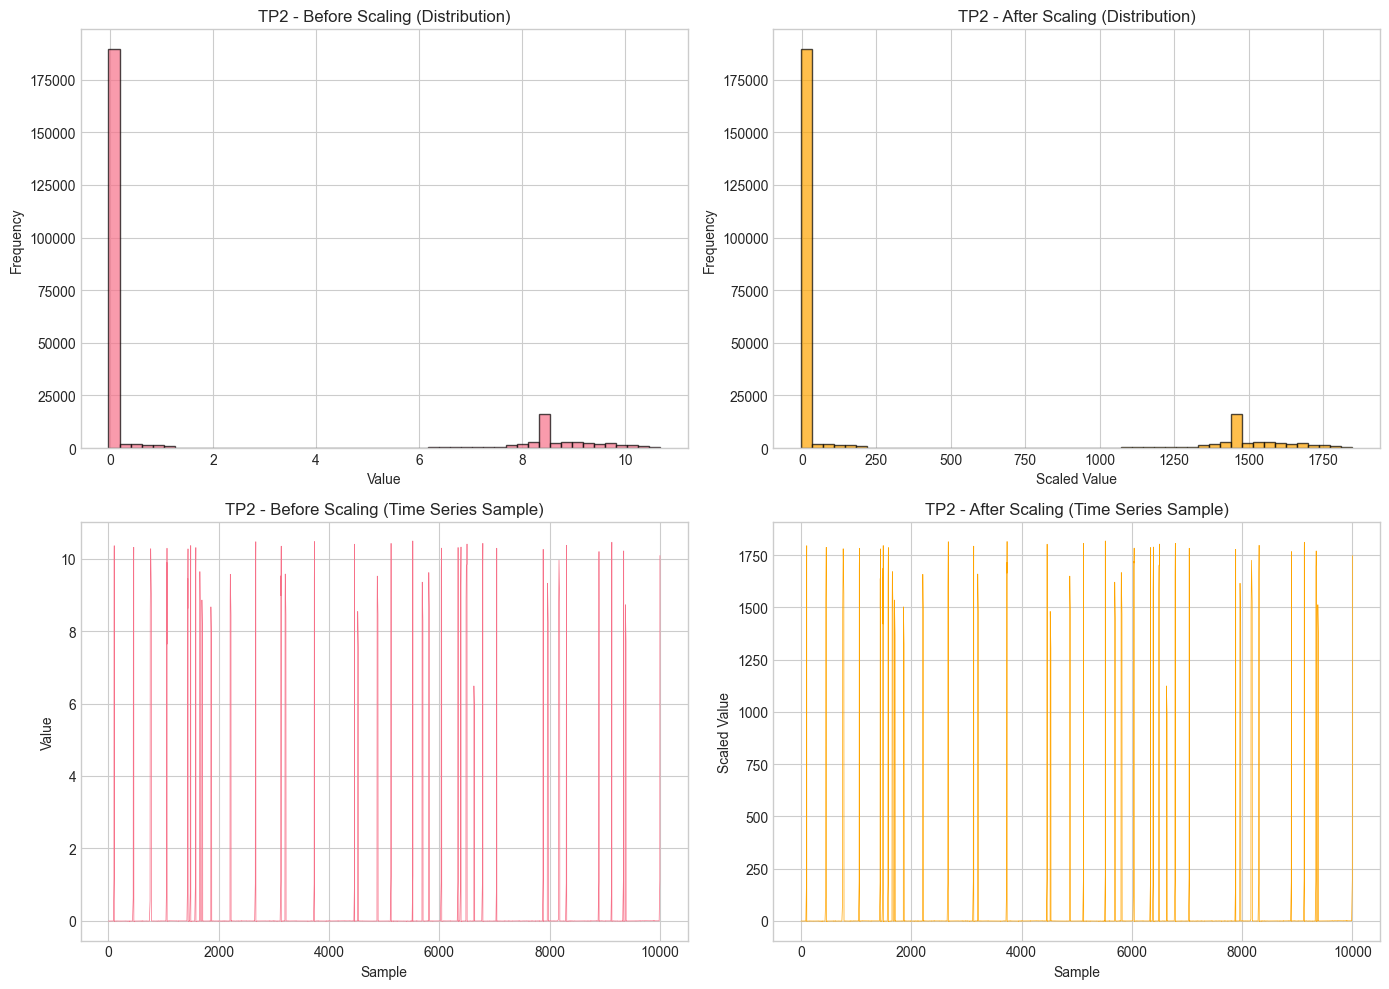

In [19]:
# -----------------------------------------------------------------------------
# 5.3 Visualize Scaling Effect
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select a sample column to visualize
sample_col = original_columns[0]

# Before scaling - Distribution
axes[0, 0].hist(train_df[sample_col], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title(f'{sample_col} - Before Scaling (Distribution)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

# After scaling - Distribution
axes[0, 1].hist(train_scaled[sample_col], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title(f'{sample_col} - After Scaling (Distribution)')
axes[0, 1].set_xlabel('Scaled Value')
axes[0, 1].set_ylabel('Frequency')

# Before scaling - Time series (sample)
sample_size = min(10000, len(train_df))
axes[1, 0].plot(train_df[sample_col].iloc[:sample_size].values, linewidth=0.5)
axes[1, 0].set_title(f'{sample_col} - Before Scaling (Time Series Sample)')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Value')

# After scaling - Time series (sample)
axes[1, 1].plot(train_scaled[sample_col].iloc[:sample_size].values, linewidth=0.5, color='orange')
axes[1, 1].set_title(f'{sample_col} - After Scaling (Time Series Sample)')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].set_ylabel('Scaled Value')

plt.tight_layout()
plt.show()

# Section 6: Sequence Creation for Deep Learning
Create sliding window sequences for LSTM/Autoencoder models.

In [20]:
# -----------------------------------------------------------------------------
# 6.1 Sequence Creation Function
# -----------------------------------------------------------------------------
def create_sequences(data, seq_length, stride=1):
    """
    Create sliding window sequences for deep learning models.
    
    For anomaly detection with autoencoders:
    - Input and output are the same (reconstruction)
    - Each sequence is a window of consecutive samples
    
    Parameters:
    - data: DataFrame or array of shape (n_samples, n_features)
    - seq_length: Number of time steps per sequence
    - stride: Step size between sequences
    
    Returns:
    - sequences: Array of shape (n_sequences, seq_length, n_features)
    - timestamps: Array of end timestamps for each sequence
    """
    if isinstance(data, pd.DataFrame):
        values = data.values
        index = data.index
    else:
        values = data
        index = None
    
    n_samples, n_features = values.shape
    n_sequences = (n_samples - seq_length) // stride + 1
    
    sequences = np.zeros((n_sequences, seq_length, n_features))
    timestamps = [] if index is not None else None
    
    for i in range(n_sequences):
        start_idx = i * stride
        end_idx = start_idx + seq_length
        sequences[i] = values[start_idx:end_idx]
        if index is not None:
            timestamps.append(index[end_idx - 1])
    
    return sequences, np.array(timestamps) if timestamps else None

print("SEQUENCE CREATION FOR DEEP LEARNING")
print("=" * 60)
print(f"Sequence length: {CONFIG['sequence_length']} samples")
print(f"Stride: {CONFIG['sequence_stride']} sample(s)")
print(f"Sequence duration: {CONFIG['sequence_length'] * CONFIG['sample_interval_seconds']} seconds")

SEQUENCE CREATION FOR DEEP LEARNING
Sequence length: 30 samples
Stride: 1 sample(s)
Sequence duration: 300 seconds


In [21]:
# -----------------------------------------------------------------------------
# 6.2 Create Sequences for Each Split
# -----------------------------------------------------------------------------
# Create sequences for training
X_train, train_timestamps = create_sequences(
    train_scaled,
    seq_length=CONFIG['sequence_length'],
    stride=CONFIG['sequence_stride']
)

# Create sequences for validation
X_val, val_timestamps = create_sequences(
    val_scaled,
    seq_length=CONFIG['sequence_length'],
    stride=CONFIG['sequence_stride']
)

# Create sequences for testing
X_test, test_timestamps = create_sequences(
    test_scaled,
    seq_length=CONFIG['sequence_length'],
    stride=CONFIG['sequence_stride']
)

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape} (n_sequences, seq_length, n_features)")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

print(f"\nMemory usage:")
print(f"  X_train: {X_train.nbytes / 1e6:.2f} MB")
print(f"  X_val:   {X_val.nbytes / 1e6:.2f} MB")
print(f"  X_test:  {X_test.nbytes / 1e6:.2f} MB")


Sequence shapes:
  X_train: (243283, 30, 165) (n_sequences, seq_length, n_features)
  X_val:   (52109, 30, 165)
  X_test:  (52110, 30, 165)

Memory usage:
  X_train: 9634.01 MB
  X_val:   2063.52 MB
  X_test:  2063.56 MB


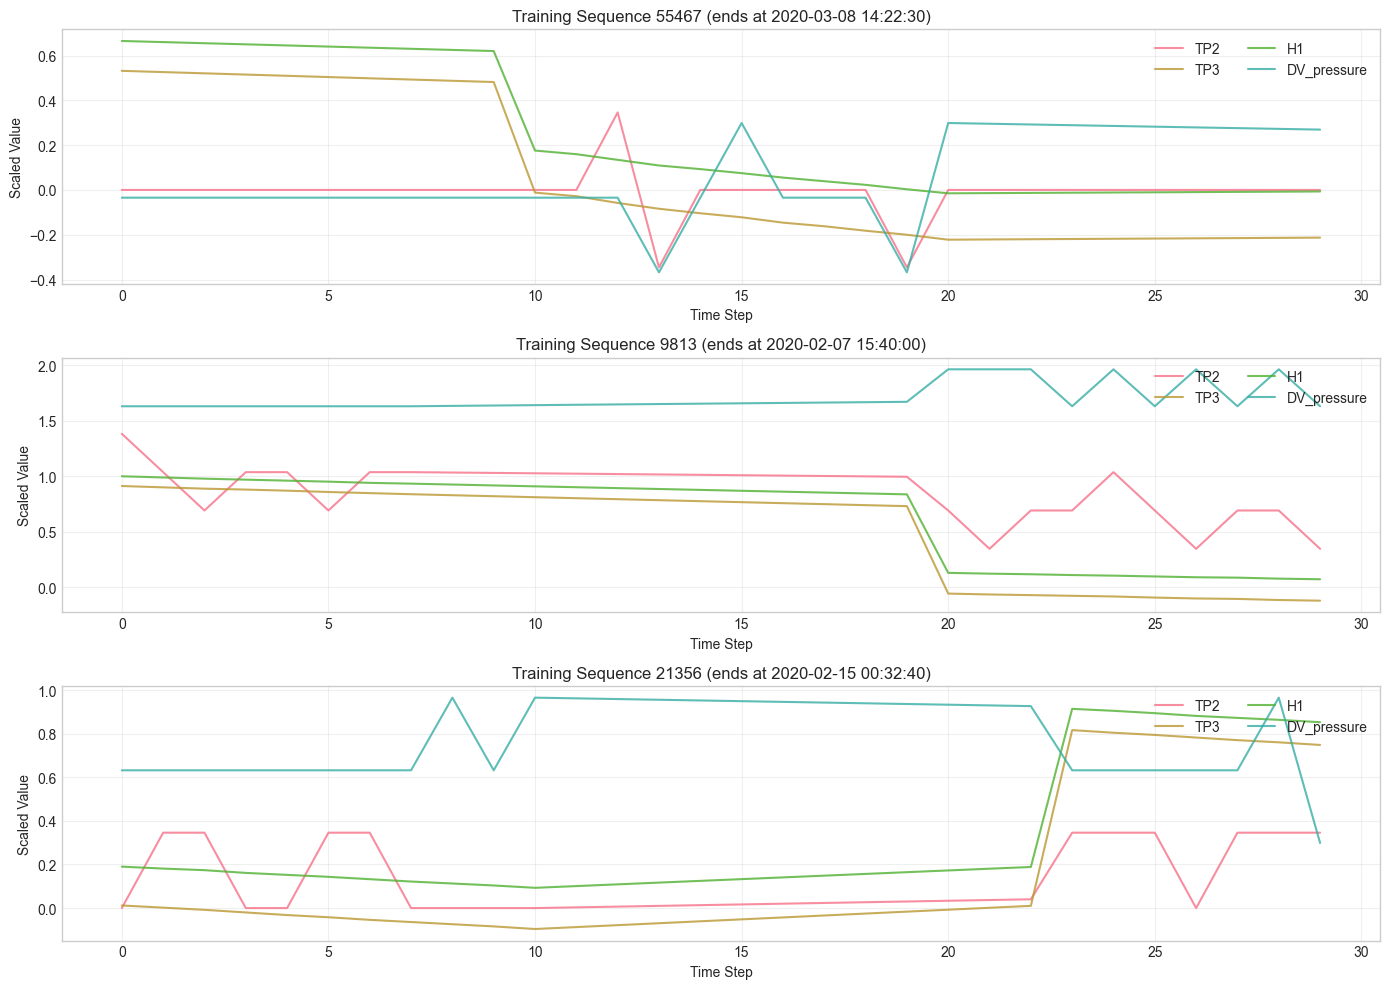

In [22]:
# -----------------------------------------------------------------------------
# 6.3 Visualize Sample Sequences
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Select indices for original sensor columns only
original_col_indices = [i for i, col in enumerate(feature_names) if col in original_columns]

# Plot 3 random training sequences
np.random.seed(42)
sample_indices = np.random.choice(len(X_train), 3, replace=False)

for ax, idx in zip(axes, sample_indices):
    sequence = X_train[idx]
    
    for i, col_idx in enumerate(original_col_indices[:4]):  # Plot first 4 original sensors
        ax.plot(sequence[:, col_idx], label=original_columns[i], alpha=0.8)
    
    ax.set_title(f'Training Sequence {idx} (ends at {train_timestamps[idx]})')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Scaled Value')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Section 7: Save Preprocessed Data
Save all preprocessed data and preprocessing artifacts for model training.

In [ ]:
# -----------------------------------------------------------------------------
# 7.1 Save Numpy Arrays (For Deep Learning)
# -----------------------------------------------------------------------------
print("SAVING PREPROCESSED DATA")
print("=" * 60)

# Save sequences as numpy arrays
np.save(f'{OUTPUT_DIR}/X_train.npy', X_train)
np.save(f'{OUTPUT_DIR}/X_val.npy', X_val)
np.save(f'{OUTPUT_DIR}/X_test.npy', X_test)

print("Saved sequence arrays:")
print(f"  {OUTPUT_DIR}/X_train.npy")
print(f"  {OUTPUT_DIR}/X_val.npy")
print(f"  {OUTPUT_DIR}/X_test.npy")

# Save timestamps
np.save(f'{OUTPUT_DIR}/train_timestamps.npy', train_timestamps)
np.save(f'{OUTPUT_DIR}/val_timestamps.npy', val_timestamps)
np.save(f'{OUTPUT_DIR}/test_timestamps.npy', test_timestamps)

print("\nSaved timestamp arrays:")
print(f"  {OUTPUT_DIR}/train_timestamps.npy")
print(f"  {OUTPUT_DIR}/val_timestamps.npy")
print(f"  {OUTPUT_DIR}/test_timestamps.npy")

In [ ]:
# -----------------------------------------------------------------------------
# 7.2 Save DataFrames (For Traditional ML / Analysis)
# -----------------------------------------------------------------------------
# Save scaled DataFrames as CSV
train_scaled.to_csv(f'{OUTPUT_DIR}/train_scaled.csv')
val_scaled.to_csv(f'{OUTPUT_DIR}/val_scaled.csv')
test_scaled.to_csv(f'{OUTPUT_DIR}/test_scaled.csv')

print("Saved scaled DataFrames:")
print(f"  {OUTPUT_DIR}/train_scaled.csv")
print(f"  {OUTPUT_DIR}/val_scaled.csv")
print(f"  {OUTPUT_DIR}/test_scaled.csv")

In [ ]:
# -----------------------------------------------------------------------------
# 7.3 Save Scaler and Configuration
# -----------------------------------------------------------------------------
# Save scaler for inference
with open(f'{OUTPUT_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open(f'{OUTPUT_DIR}/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Save original column names
with open(f'{OUTPUT_DIR}/original_columns.pkl', 'wb') as f:
    pickle.dump(original_columns, f)

# Save configuration
with open(f'{OUTPUT_DIR}/config.pkl', 'wb') as f:
    pickle.dump(CONFIG, f)

print("\nSaved preprocessing artifacts:")
print(f"  {OUTPUT_DIR}/scaler.pkl")
print(f"  {OUTPUT_DIR}/feature_names.pkl")
print(f"  {OUTPUT_DIR}/original_columns.pkl")
print(f"  {OUTPUT_DIR}/config.pkl")

In [ ]:
# -----------------------------------------------------------------------------
# 7.4 Preprocessing Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("               PREPROCESSING COMPLETE - SUMMARY")
print("=" * 70)

print(f"""
DATASET INFORMATION:
  Original samples:     {len(df):,}
  After preprocessing:  {len(df_features):,}
  
FEATURES:
  Original features:    {len(original_columns)}
  Engineered features:  {len(feature_names) - len(original_columns)}
  Total features:       {len(feature_names)}
  
DATA SPLITS:
  Train samples:        {len(train_scaled):,} ({CONFIG['train_ratio']*100:.0f}%)
  Validation samples:   {len(val_scaled):,} ({CONFIG['val_ratio']*100:.0f}%)
  Test samples:         {len(test_scaled):,} ({CONFIG['test_ratio']*100:.0f}%)
  
SEQUENCES (for Deep Learning):
  Sequence length:      {CONFIG['sequence_length']} samples ({CONFIG['sequence_length'] * CONFIG['sample_interval_seconds']}s)
  Train sequences:      {X_train.shape[0]:,}
  Validation sequences: {X_val.shape[0]:,}
  Test sequences:       {X_test.shape[0]:,}
  Sequence shape:       (seq_length={CONFIG['sequence_length']}, n_features={len(feature_names)})
  
SCALING:
  Scaler type:          {CONFIG['scaler_type'].upper()}
  Fitted on:            Training data only
  
OUTPUT FILES:
  Directory:            {OUTPUT_DIR}/
""")

print("\nNEXT STEPS:")
print("-" * 70)
print("  1. Load preprocessed data in model training notebook")
print("  2. Build anomaly detection model (LSTM-Autoencoder, etc.)")
print("  3. Train on X_train, validate on X_val")
print("  4. Evaluate on X_test and compute reconstruction error")
print("  5. Set anomaly threshold based on validation errors")
print("\n" + "=" * 70)

# Appendix: Loading Preprocessed Data
Example code for loading the saved preprocessed data in a separate notebook.

In [ ]:
# -----------------------------------------------------------------------------
# Example: Loading Preprocessed Data (for use in other notebooks)
# -----------------------------------------------------------------------------
"""
# Copy this code to your model training notebook

import numpy as np
import pickle

# Directory where preprocessed data is saved
DATA_DIR = 'preprocessed_data'

# Load sequences
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_val = np.load(f'{DATA_DIR}/X_val.npy')
X_test = np.load(f'{DATA_DIR}/X_test.npy')

# Load timestamps
train_timestamps = np.load(f'{DATA_DIR}/train_timestamps.npy', allow_pickle=True)
val_timestamps = np.load(f'{DATA_DIR}/val_timestamps.npy', allow_pickle=True)
test_timestamps = np.load(f'{DATA_DIR}/test_timestamps.npy', allow_pickle=True)

# Load scaler (for inverse transform if needed)
with open(f'{DATA_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load configuration
with open(f'{DATA_DIR}/config.pkl', 'rb') as f:
    config = pickle.load(f)

# Load feature names
with open(f'{DATA_DIR}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print(f"Loaded X_train: {X_train.shape}")
print(f"Loaded X_val: {X_val.shape}")
print(f"Loaded X_test: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
"""
print("Example loading code shown above (commented). Copy to your training notebook.")